In [1]:
from statsbombpy import sb
import pandas as pd

In [23]:
events.shape

(3211, 91)

In [24]:
events.columns.tolist()

['bad_behaviour_card',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'block_offensive',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_type',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_length',
 'pass_miscommunication',
 'pa

In [25]:
events[["type", "team", "player", "minute", "location"]].head(15)

,type,team,player,minute,location
0,Starting XI,Serbia,NaN,0,NaN
1,Starting XI,Switzerland,NaN,0,NaN
2,Half Start,Switzerland,NaN,0,NaN
3,Half Start,Serbia,NaN,0,NaN
4,Half Start,Serbia,NaN,45,NaN
5,Half Start,Switzerland,NaN,45,NaN
6,Pass,Switzerland,Breel-Donald Embolo,0,"[61.0, 40.1]"
7,Pass,Switzerland,Remo Freuler,0,"[39.7, 45.5]"
8,Pass,Switzerland,Silvan Widmer,0,"[42.3, 72.2]"
9,Pass,Switzerland,Fabian Lukas Schär,0,"[23.1, 62.4]"


In [26]:
events["type"].value_counts()

type
Pass                 966
Ball Receipt*        907
Carry                667
Pressure             177
Ball Recovery         92
Duel                  68
Block                 40
Clearance             36
Foul Committed        35
Foul Won              34
Goal Keeper           30
Shot                  26
Miscontrol            25
Interception          23
Dispossessed          23
Dribble               12
Injury Stoppage       10
Substitution           9
Dribbled Past          6
Referee Ball-Drop      4
Half Start             4
Half End               4
Bad Behaviour          4
Tactical Shift         2
Starting XI            2
Error                  2
Player Off             1
Player On              1
Shield                 1
Name: count, dtype: int64

In [27]:
important_cols = [
    "type",
    "team",
    "player",
    "minute",
    "location",
    "shot_outcome",
    "pass_outcome",
    "pass_end_location",
    "carry_end_location",
    "dribble_outcome",
    "duel_outcome",
    "foul_committed_card",
    "goalkeeper_outcome"
]

for col in important_cols:
    if col in events.columns:
        print(f"{col}: {events[col].notna().sum()} non-null values")
    else:
        print(f"{col}: NOT AVAILABLE")

type: 3211 non-null values
team: 3211 non-null values
player: 3195 non-null values
minute: 3211 non-null values
location: 3174 non-null values
shot_outcome: 26 non-null values
pass_outcome: 213 non-null values
pass_end_location: 966 non-null values
carry_end_location: 667 non-null values
dribble_outcome: 12 non-null values
duel_outcome: 29 non-null values
foul_committed_card: 7 non-null values
goalkeeper_outcome: 15 non-null values


In [2]:
competitions = sb.competitions()
competitions.head()

c:\Users\emirc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


In [5]:
competitions[["competition_id", "season_id", "country_name", "competition_name", "season_name"]].drop_duplicates().head(50)

,competition_id,season_id,country_name,competition_name,season_name
0,9,281,Germany,1. Bundesliga,2023/2024
1,9,27,Germany,1. Bundesliga,2015/2016
2,1267,107,Africa,African Cup of Nations,2023
3,16,4,Europe,Champions League,2018/2019
4,16,1,Europe,Champions League,2017/2018
5,16,2,Europe,Champions League,2016/2017
6,16,27,Europe,Champions League,2015/2016
7,16,26,Europe,Champions League,2014/2015
8,16,25,Europe,Champions League,2013/2014
9,16,24,Europe,Champions League,2012/2013


In [4]:
competition_id = 43
season_id = 106

matches = sb.matches(competition_id=competition_id, season_id=season_id)
matches.head()

c:\Users\emirc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3857256,2022-12-02,21:00:00.000,International - FIFA World Cup,2022,Serbia,Switzerland,2,3,available,...,2023-04-26T23:49:58.956186,3,Group Stage,Stadium 974,Fernando Andrés Rapallini,Dragan Stojković,Murat Yakin,1.1.0,2,2
1,3869151,2022-12-03,21:00:00.000,International - FIFA World Cup,2022,Argentina,Australia,2,1,available,...,2023-07-30T07:48:51.865595,4,Round of 16,Ahmad bin Ali Stadium,Szymon Marciniak,Lionel Sebastián Scaloni,Graham James Arnold,1.1.0,2,2
2,3857257,2022-11-30,17:00:00.000,International - FIFA World Cup,2022,Australia,Denmark,1,0,available,...,2023-06-20T11:04:37.638969,3,Group Stage,Al Janoub Stadium,Mustapha Ghorbal,Graham James Arnold,Kasper Hjulmand,1.1.0,2,2
3,3857258,2022-11-24,21:00:00.000,International - FIFA World Cup,2022,Brazil,Serbia,2,0,available,...,2023-07-11T14:56:31.096588,1,Group Stage,Lusail Stadium,Alireza Faghani,Telê Santana da Silva,Dragan Stojković,1.1.0,2,2
4,3857288,2022-11-26,12:00:00.000,International - FIFA World Cup,2022,Tunisia,Australia,0,1,available,...,2023-04-27T00:30:07.835815,2,Group Stage,Al Janoub Stadium,Daniel Siebert,Jalel Kadri,Graham James Arnold,1.1.0,2,2


In [6]:
matches[["match_id", "home_team", "away_team", "match_date"]].head(15)

,match_id,home_team,away_team,match_date
0,3857256,Serbia,Switzerland,2022-12-02
1,3869151,Argentina,Australia,2022-12-03
2,3857257,Australia,Denmark,2022-11-30
3,3857258,Brazil,Serbia,2022-11-24
4,3857288,Tunisia,Australia,2022-11-26
5,3857267,Ecuador,Senegal,2022-11-29
6,3869321,Netherlands,Argentina,2022-12-09
7,3857287,Uruguay,South Korea,2022-11-24
8,3869486,Morocco,Portugal,2022-12-10
9,3869685,Argentina,France,2022-12-18


In [7]:
match_id = matches.iloc[0]["match_id"]
events = sb.events(match_id=match_id)
events.head()

c:\Users\emirc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 3412, 'lineup': [{'player': {'id...",Serbia,786,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Switzerland,773,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Switzerland,773,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Serbia,786,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Serbia,786,00:00:00.000,Half Start,NaN


In [8]:
shots = events[events["type"] == "Shot"].copy()
shots.head()

,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
2674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Switzerland,773,00:00:18.696,Shot,NaN
2675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Switzerland,773,00:00:22.129,Shot,NaN
2676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Switzerland,773,00:00:23.845,Shot,NaN
2677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Serbia,786,00:04:35.297,Shot,NaN
2678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Serbia,786,00:10:05.636,Shot,NaN


In [10]:
shots[["player", "team", "minute", "location", "shot_outcome"]].head(20)

,player,team,minute,location,shot_outcome
2674,Granit Xhaka,Switzerland,0,"[96.0, 38.8]",Blocked
2675,Breel-Donald Embolo,Switzerland,0,"[113.1, 40.7]",Saved
2676,Granit Xhaka,Switzerland,0,"[103.8, 41.9]",Saved
2677,Nikola Milenković,Serbia,4,"[112.2, 36.8]",Off T
2678,Andrija Živković,Serbia,10,"[97.8, 51.5]",Post
2679,Dušan Vlahović,Serbia,10,"[115.4, 38.6]",Saved
2680,Remo Freuler,Switzerland,13,"[107.8, 35.9]",Blocked
2681,Xherdan Shaqiri,Switzerland,19,"[107.5, 50.6]",Goal
2682,Granit Xhaka,Switzerland,21,"[97.3, 33.7]",Saved
2683,Dušan Vlahović,Serbia,22,"[109.6, 35.4]",Saved


In [11]:
shots.to_csv("../data/raw/shots_single_match.csv", index=False)
matches.to_csv("../data/raw/world_cup_2022_matches.csv", index=False)

In [12]:
shots[["team", "player", "minute", "shot_outcome", "location"]].head(15)

,team,player,minute,shot_outcome,location
2674,Switzerland,Granit Xhaka,0,Blocked,"[96.0, 38.8]"
2675,Switzerland,Breel-Donald Embolo,0,Saved,"[113.1, 40.7]"
2676,Switzerland,Granit Xhaka,0,Saved,"[103.8, 41.9]"
2677,Serbia,Nikola Milenković,4,Off T,"[112.2, 36.8]"
2678,Serbia,Andrija Živković,10,Post,"[97.8, 51.5]"
2679,Serbia,Dušan Vlahović,10,Saved,"[115.4, 38.6]"
2680,Switzerland,Remo Freuler,13,Blocked,"[107.8, 35.9]"
2681,Switzerland,Xherdan Shaqiri,19,Goal,"[107.5, 50.6]"
2682,Switzerland,Granit Xhaka,21,Saved,"[97.3, 33.7]"
2683,Serbia,Dušan Vlahović,22,Saved,"[109.6, 35.4]"


In [13]:
shots["shot_outcome"].value_counts()

shot_outcome
Off T      7
Blocked    6
Saved      6
Goal       5
Post       1
Wayward    1
Name: count, dtype: int64

In [14]:
shots["x"] = shots["location"].apply(lambda loc: loc[0] if isinstance(loc, list) and len(loc) >= 2 else None)
shots["y"] = shots["location"].apply(lambda loc: loc[1] if isinstance(loc, list) and len(loc) >= 2 else None)

shots[["team", "player", "x", "y", "shot_outcome"]].head()

,team,player,x,y,shot_outcome
2674,Switzerland,Granit Xhaka,96.0,38.8,Blocked
2675,Switzerland,Breel-Donald Embolo,113.1,40.7,Saved
2676,Switzerland,Granit Xhaka,103.8,41.9,Saved
2677,Serbia,Nikola Milenković,112.2,36.8,Off T
2678,Serbia,Andrija Živković,97.8,51.5,Post


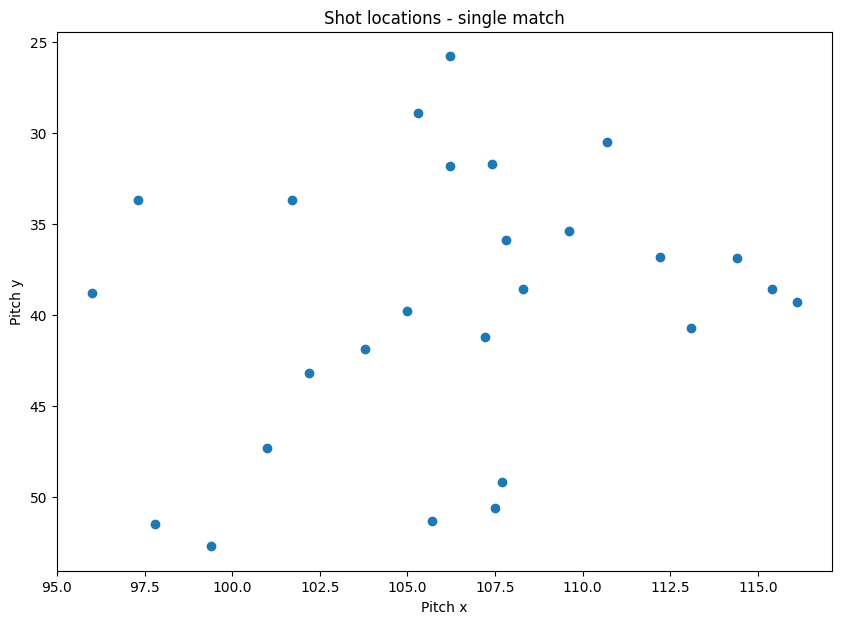

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(shots["x"], shots["y"])
plt.gca().invert_yaxis()
plt.title("Shot locations - single match")
plt.xlabel("Pitch x")
plt.ylabel("Pitch y")
plt.show()

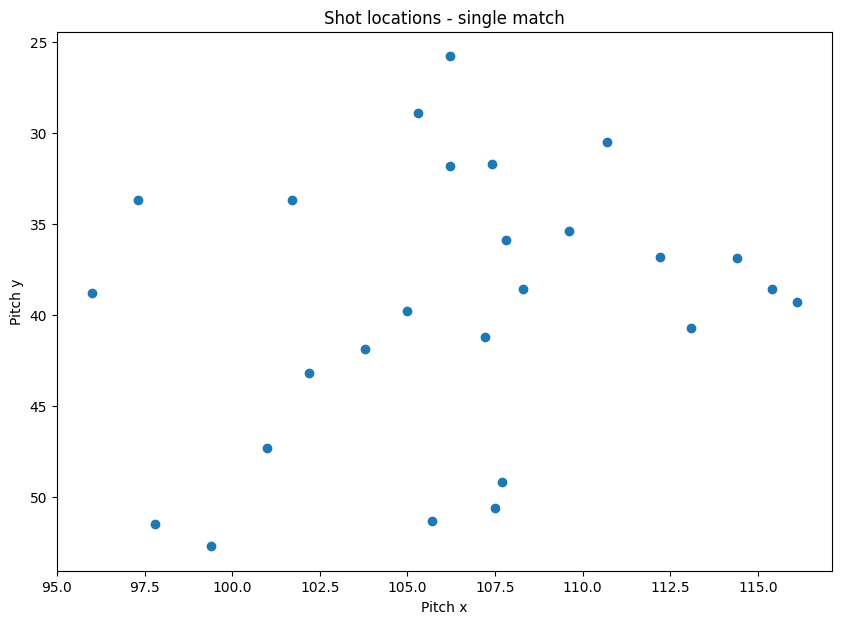

In [16]:
plt.figure(figsize=(10, 7))
plt.scatter(shots["x"], shots["y"])
plt.gca().invert_yaxis()
plt.title("Shot locations - single match")
plt.xlabel("Pitch x")
plt.ylabel("Pitch y")
plt.savefig("../figures/shot_map_single_match.png", dpi=300, bbox_inches="tight")
plt.show()

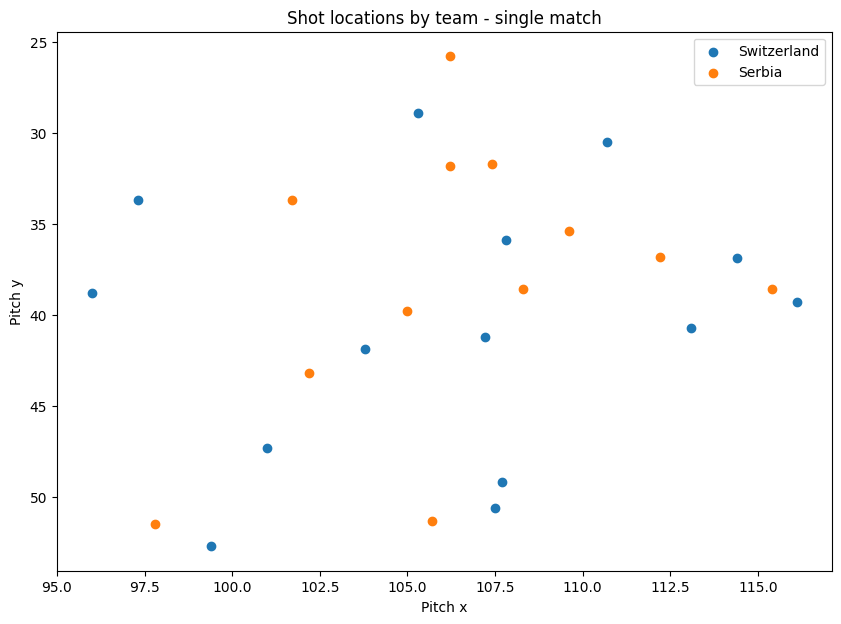

In [17]:
plt.figure(figsize=(10, 7))

for team_name in shots["team"].dropna().unique():
    team_shots = shots[shots["team"] == team_name]
    plt.scatter(team_shots["x"], team_shots["y"], label=team_name)

plt.gca().invert_yaxis()
plt.title("Shot locations by team - single match")
plt.xlabel("Pitch x")
plt.ylabel("Pitch y")
plt.legend()
plt.show()

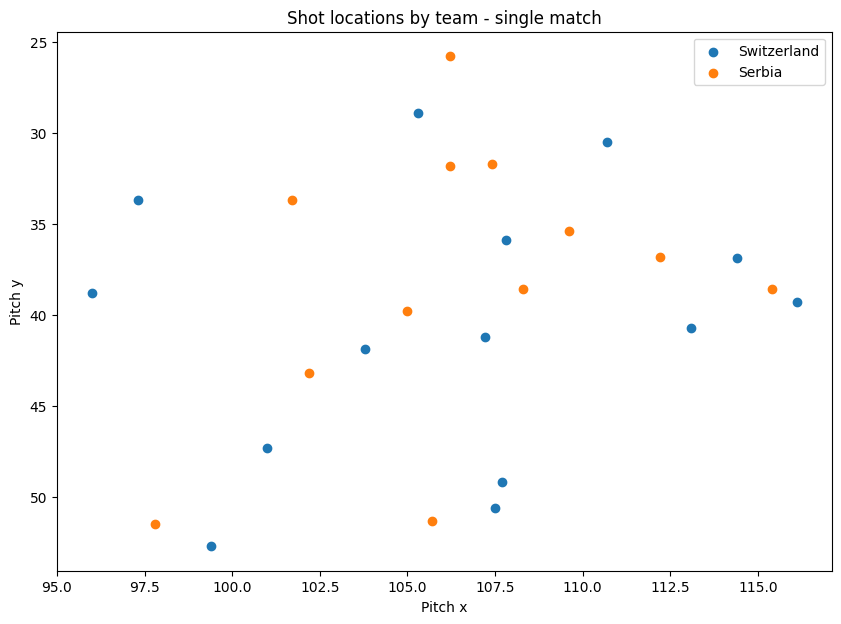

In [18]:
plt.figure(figsize=(10, 7))

for team_name in shots["team"].dropna().unique():
    team_shots = shots[shots["team"] == team_name]
    plt.scatter(team_shots["x"], team_shots["y"], label=team_name)

plt.gca().invert_yaxis()
plt.title("Shot locations by team - single match")
plt.xlabel("Pitch x")
plt.ylabel("Pitch y")
plt.legend()
plt.savefig("../figures/shot_map_by_team.png", dpi=300, bbox_inches="tight")
plt.show()

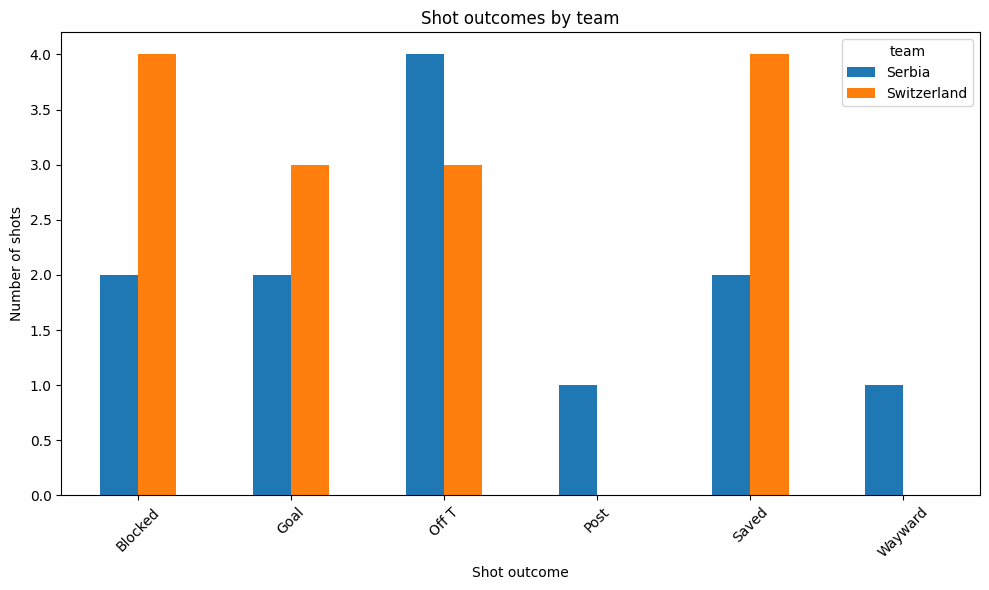

In [31]:
outcome_counts = shots.groupby(["team", "shot_outcome"]).size().reset_index(name="count")
outcome_pivot = outcome_counts.pivot(index="shot_outcome", columns="team", values="count").fillna(0)


outcome_pivot.plot(kind="bar", figsize=(10, 6))
plt.title("Shot outcomes by team")
plt.xlabel("Shot outcome")
plt.ylabel("Number of shots")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/shot_outcomes_by_team.png", dpi=300, bbox_inches="tight")
plt.show()

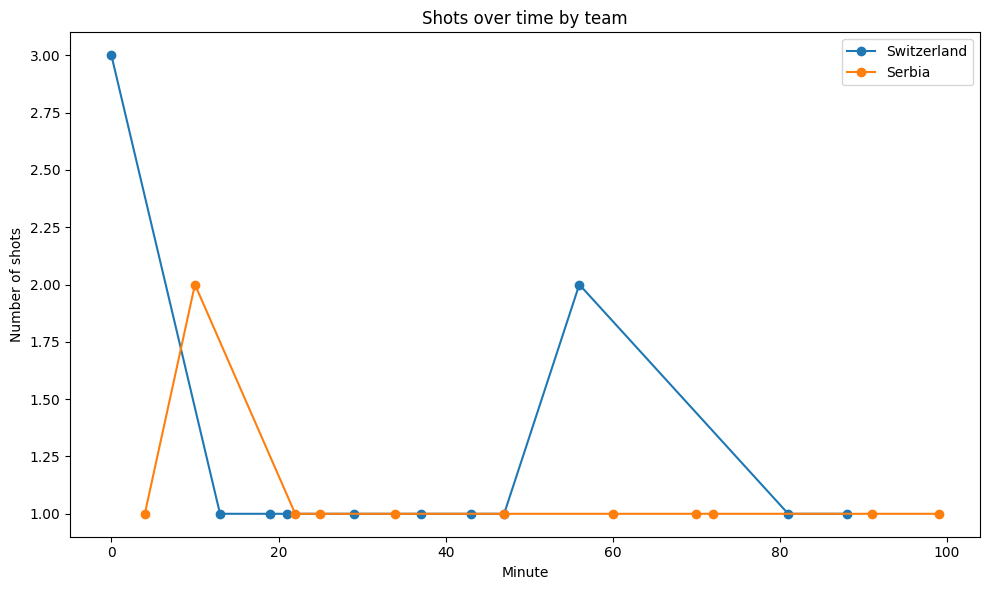

In [22]:
shot_minutes = shots.groupby(["minute", "team"]).size().reset_index(name="count")

plt.figure(figsize=(10, 6))
for team_name in shot_minutes["team"].dropna().unique():
    team_data = shot_minutes[shot_minutes["team"] == team_name]
    plt.plot(team_data["minute"], team_data["count"], marker="o", label=team_name)

plt.title("Shots over time by team")
plt.xlabel("Minute")
plt.ylabel("Number of shots")
plt.legend()
plt.tight_layout()
plt.show()

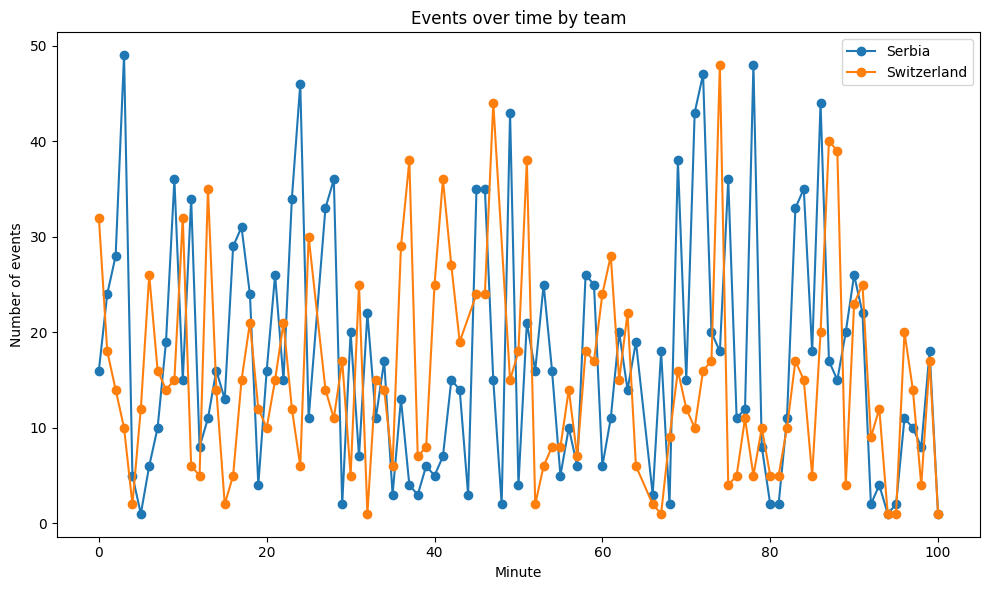

In [30]:
event_minutes = events.groupby(["minute", "team"]).size().reset_index(name="count")

plt.figure(figsize=(10, 6))
for team_name in event_minutes["team"].dropna().unique():
    team_data = event_minutes[event_minutes["team"] == team_name]
    plt.plot(team_data["minute"], team_data["count"], marker="o", label=team_name)

plt.title("Events over time by team")
plt.xlabel("Minute")
plt.ylabel("Number of events")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/events_over_time_by_team.png", dpi=300, bbox_inches="tight")
plt.show()

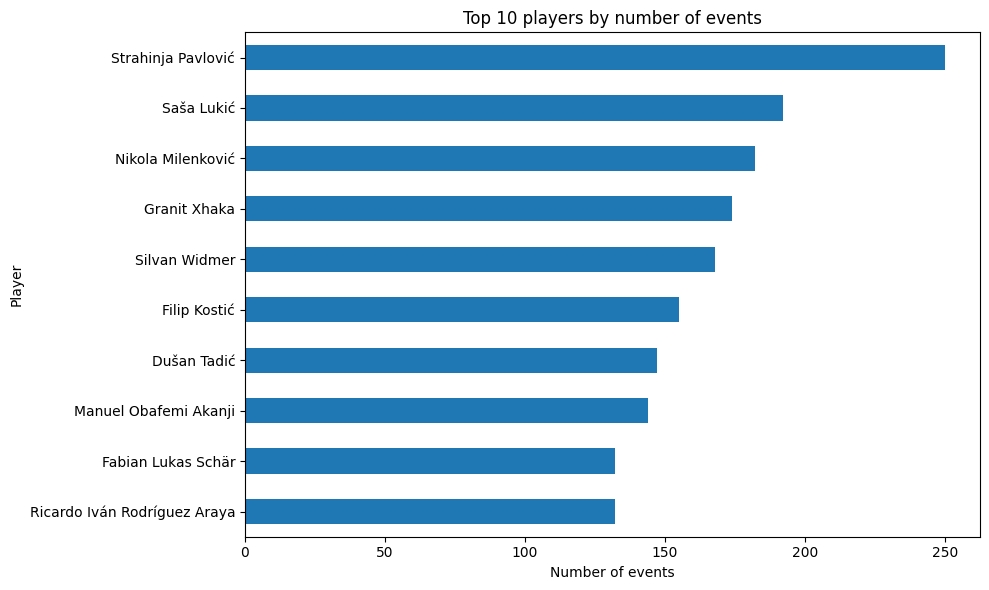

In [32]:
top_players = events["player"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_players.sort_values().plot(kind="barh")
plt.title("Top 10 players by number of events")
plt.xlabel("Number of events")
plt.ylabel("Player")
plt.tight_layout()
plt.savefig("../figures/top_10_players_by_events.png", dpi=300, bbox_inches="tight")
plt.show()

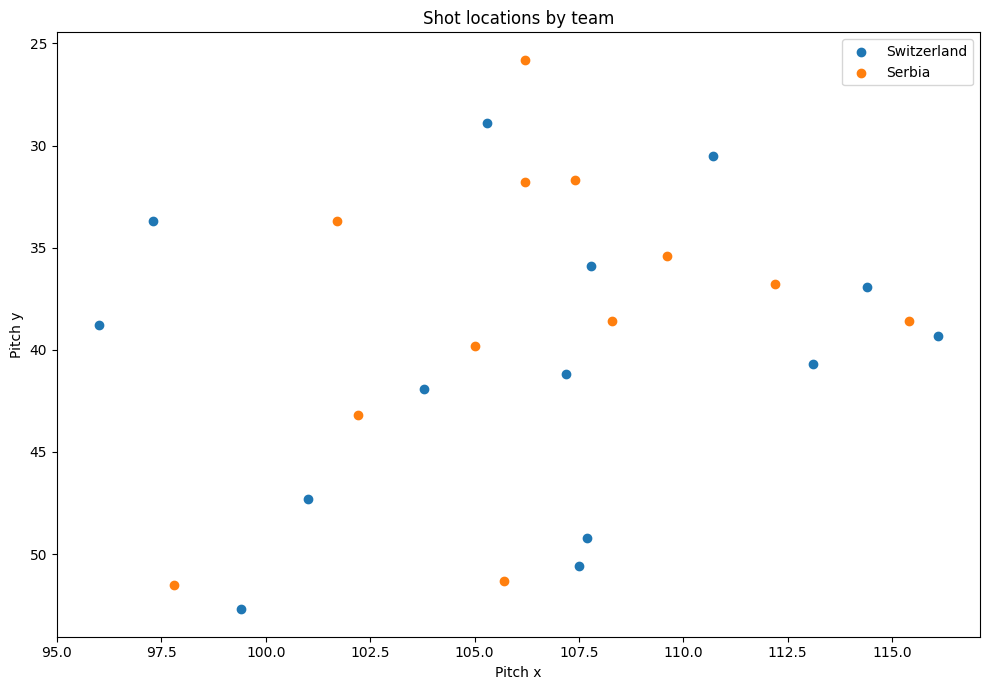

In [33]:
plt.figure(figsize=(10, 7))

for team_name in shots["team"].dropna().unique():
    team_shots = shots[shots["team"] == team_name]
    plt.scatter(team_shots["x"], team_shots["y"], label=team_name)

plt.gca().invert_yaxis()
plt.title("Shot locations by team")
plt.xlabel("Pitch x")
plt.ylabel("Pitch y")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/shot_locations_by_team.png", dpi=300, bbox_inches="tight")
plt.show()

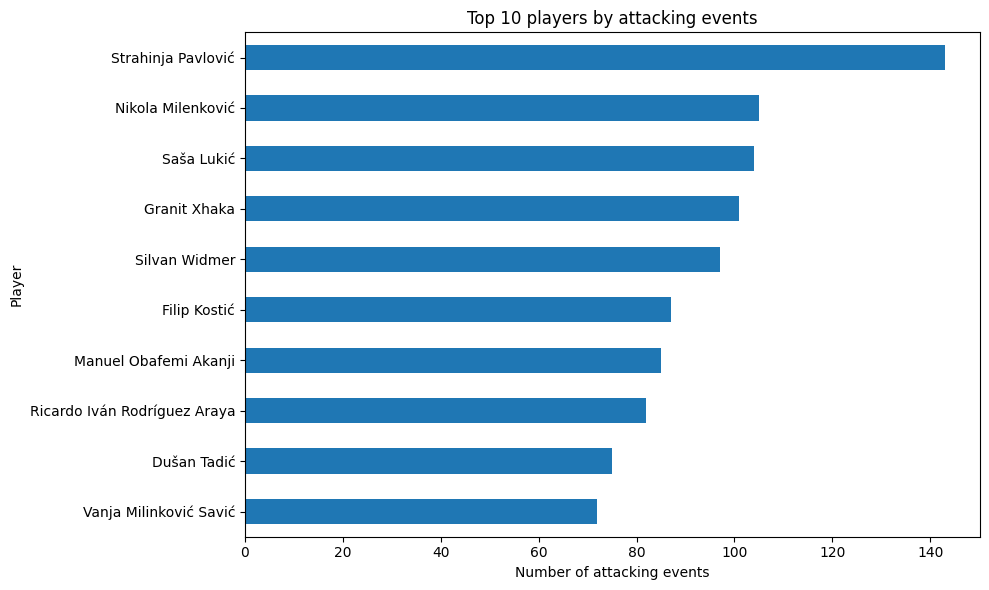

In [39]:
attacking_player_counts = attacking_events["player"].value_counts().head(10)

plt.figure(figsize=(10, 6))
attacking_player_counts.sort_values().plot(kind="barh")
plt.title("Top 10 players by attacking events")
plt.xlabel("Number of attacking events")
plt.ylabel("Player")
plt.tight_layout()
plt.savefig("../figures/gdv_06_top_players_attacking_events.png", dpi=300, bbox_inches="tight")
plt.show()

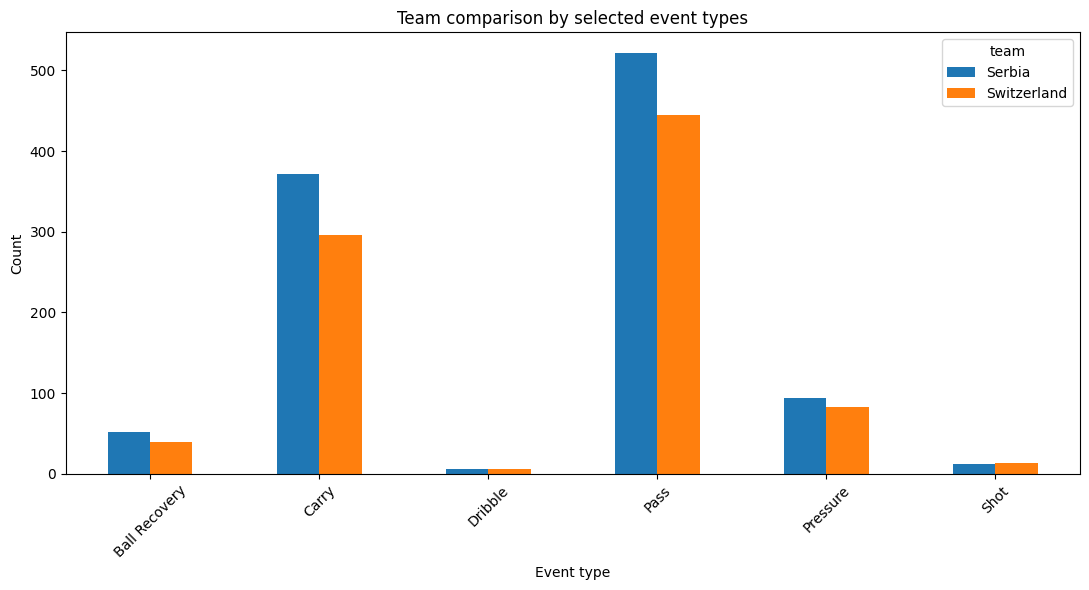

In [40]:
selected_types = ["Pass", "Carry", "Shot", "Pressure", "Ball Recovery", "Dribble"]
team_event_counts = events[events["type"].isin(selected_types)].groupby(["team", "type"]).size().reset_index(name="count")

team_event_pivot = team_event_counts.pivot(index="type", columns="team", values="count").fillna(0)

team_event_pivot.plot(kind="bar", figsize=(11, 6))
plt.title("Team comparison by selected event types")
plt.xlabel("Event type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/gdv_07_team_comparison_selected_event_types.png", dpi=300, bbox_inches="tight")
plt.show()

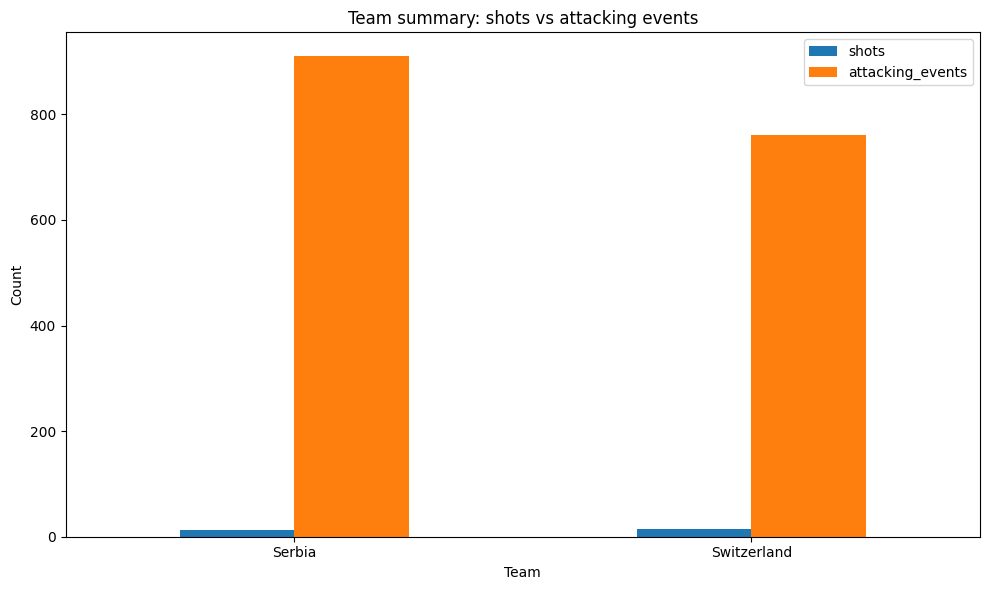

In [41]:
team_shots = shots.groupby("team").size().reset_index(name="shots")
team_attacking = attacking_events.groupby("team").size().reset_index(name="attacking_events")

team_summary = pd.merge(team_shots, team_attacking, on="team", how="outer").fillna(0)

ax = team_summary.plot(x="team", y=["shots", "attacking_events"], kind="bar", figsize=(10, 6))
plt.title("Team summary: shots vs attacking events")
plt.xlabel("Team")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../figures/gdv_08_team_summary_shots_vs_attacking_events.png", dpi=300, bbox_inches="tight")
plt.show()